# MovieLens-1M — Exploratory Data Analysis

Canonical dataset at `data/canonical/ml-1m/v1/`.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = Path("../data/canonical/ml-1m/v1")

users        = pd.read_parquet(DATA_DIR / "users.parquet")
items        = pd.read_parquet(DATA_DIR / "items.parquet")
interactions = pd.read_parquet(DATA_DIR / "interactions.parquet")

with open(DATA_DIR / "manifest.json") as f:
    manifest = json.load(f)

Matplotlib is building the font cache; this may take a moment.


In [12]:
users.head()

,user_id,raw_user_id,gender,age,occupation,zip_code
0,1,1,F,1,10,48067
1,2,2,M,56,16,70072
2,3,3,M,25,15,55117
3,4,4,M,45,7,02460
4,5,5,M,25,20,55455


In [13]:
items.head()

,item_id,raw_item_id,title,genres
0,1,1,Toy Story (1995),Animation|Children's|Comedy
1,2,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,3,Grumpier Old Men (1995),Comedy|Romance
3,4,4,Waiting to Exhale (1995),Comedy|Drama
4,5,5,Father of the Bride Part II (1995),Comedy


In [14]:
interactions.head()

,interaction_id,user_id,item_id,event_type,rating,timestamp,target_interact,target_like_ge4,target_rating
0,ml-1m:row:0000000001,1,1193,rating,5,978300760,1,1,5
1,ml-1m:row:0000000002,1,661,rating,3,978302109,1,0,3
2,ml-1m:row:0000000003,1,914,rating,3,978301968,1,0,3
3,ml-1m:row:0000000004,1,3408,rating,4,978300275,1,1,4
4,ml-1m:row:0000000005,1,2355,rating,5,978824291,1,1,5


In [17]:
assert all(interactions.rating == interactions.target_rating)
assert all(interactions.target_interact == 1)

## 1  Dataset overview

In [2]:
n_users = users["user_id"].nunique()
n_items = items["item_id"].nunique()
n_interactions = len(interactions)
density = n_interactions / (n_users * n_items)

print(f"Users        : {n_users:,}")
print(f"Items        : {n_items:,}")
print(f"Interactions : {n_interactions:,}")
print(f"Density      : {density:.4%}")
print()
print("Standard targets:")
for k, v in manifest["standard_targets"].items():
    print(f"  {k}: {v}")

Users        : 6,040
Items        : 3,883
Interactions : 1,000,209
Density      : 4.2647%

Standard targets:
  target_interact: 1 for every observed rating row in interactions.parquet.
  target_like_ge4: 1 if rating >= 4 else 0.
  target_rating: Raw MovieLens rating on the 1-5 scale.


In [3]:
print("Interactions schema:")
interactions.dtypes.to_frame("dtype")

Interactions schema:


,dtype
interaction_id,str
user_id,string
item_id,string
event_type,str
rating,Int64
timestamp,Int64
target_interact,int8
target_like_ge4,int8
target_rating,Int64


## 2  Rating and target distributions

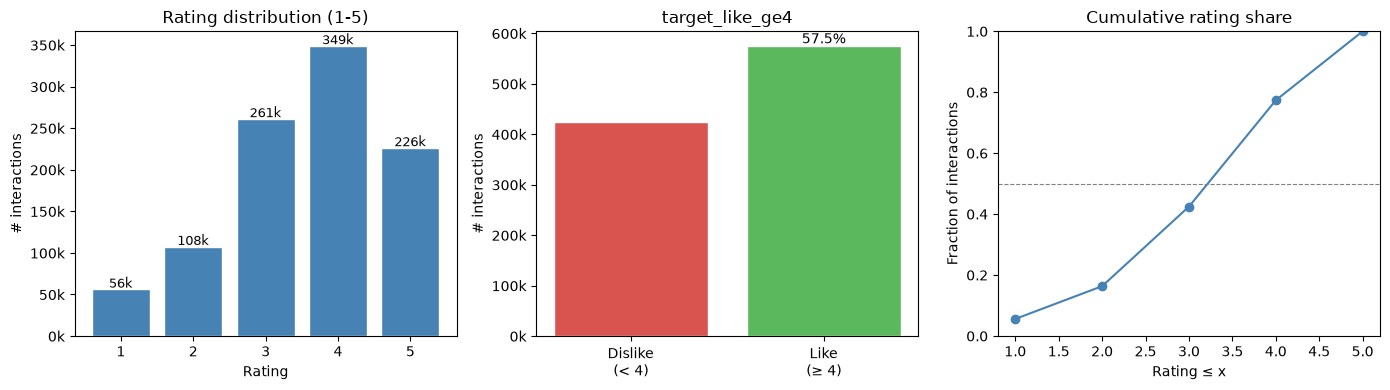

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# target_rating (1-5)
counts = interactions["target_rating"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Rating distribution (1-5)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("# interactions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f"{val/1e3:.0f}k", ha="center", fontsize=9)

# target_like_ge4
like_counts = interactions["target_like_ge4"].value_counts().sort_index()
axes[1].bar(["Dislike\n(< 4)", "Like\n(≥ 4)"], like_counts.values,
            color=["#d9534f", "#5cb85c"], edgecolor="white")
axes[1].set_title("target_like_ge4")
axes[1].set_ylabel("# interactions")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
like_pct = like_counts[1] / like_counts.sum()
axes[1].text(1, like_counts[1] + 5000, f"{like_pct:.1%}", ha="center", fontsize=10)

# cumulative rating share
cum = (counts / counts.sum()).cumsum()
axes[2].plot(cum.index, cum.values, marker="o", color="steelblue")
axes[2].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_title("Cumulative rating share")
axes[2].set_xlabel("Rating ≤ x")
axes[2].set_ylabel("Fraction of interactions")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 3  User features

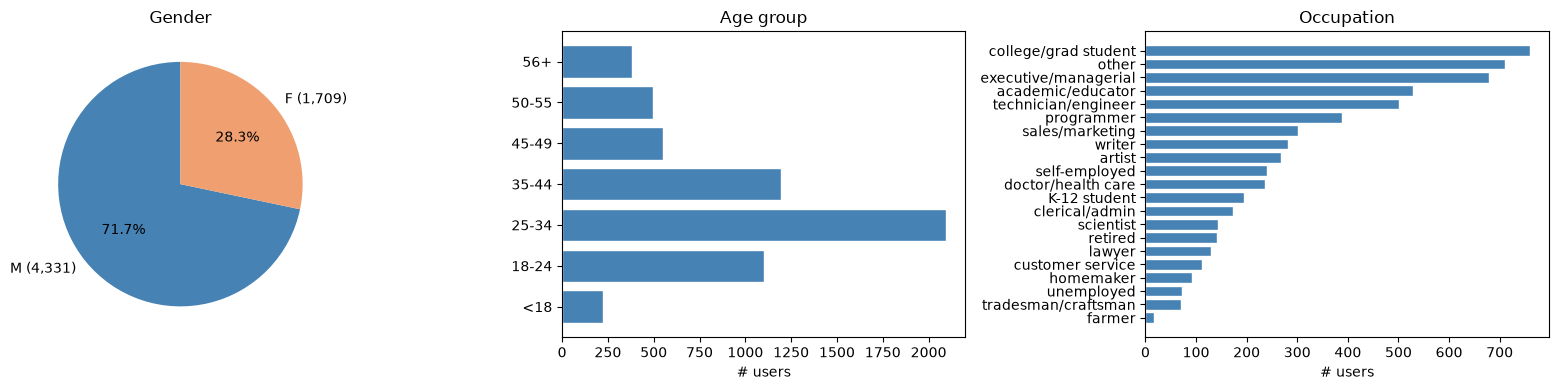

In [5]:
AGE_LABELS = {1: "<18", 18: "18-24", 25: "25-34", 35: "35-44",
              45: "45-49", 50: "50-55", 56: "56+"}

OCCUPATION_LABELS = {
    0: "other", 1: "academic/educator", 2: "artist", 3: "clerical/admin",
    4: "college/grad student", 5: "customer service", 6: "doctor/health care",
    7: "executive/managerial", 8: "farmer", 9: "homemaker", 10: "K-12 student",
    11: "lawyer", 12: "programmer", 13: "retired", 14: "sales/marketing",
    15: "scientist", 16: "self-employed", 17: "technician/engineer",
    18: "tradesman/craftsman", 19: "unemployed", 20: "writer",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gender
gender = users["gender"].value_counts()
axes[0].pie(gender.values, labels=[f"{g} ({v:,})" for g, v in gender.items()],
            colors=["steelblue", "#f0a070"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("Gender")

# Age
age_counts = users["age"].value_counts().sort_index()
age_labels = [AGE_LABELS[a] for a in age_counts.index]
axes[1].barh(age_labels, age_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("Age group")
axes[1].set_xlabel("# users")

# Occupation
occ_counts = users["occupation"].value_counts().sort_values(ascending=True)
occ_labels = [OCCUPATION_LABELS[o] for o in occ_counts.index]
axes[2].barh(occ_labels, occ_counts.values, color="steelblue", edgecolor="white")
axes[2].set_title("Occupation")
axes[2].set_xlabel("# users")

plt.tight_layout()
plt.show()

## 4  Item features

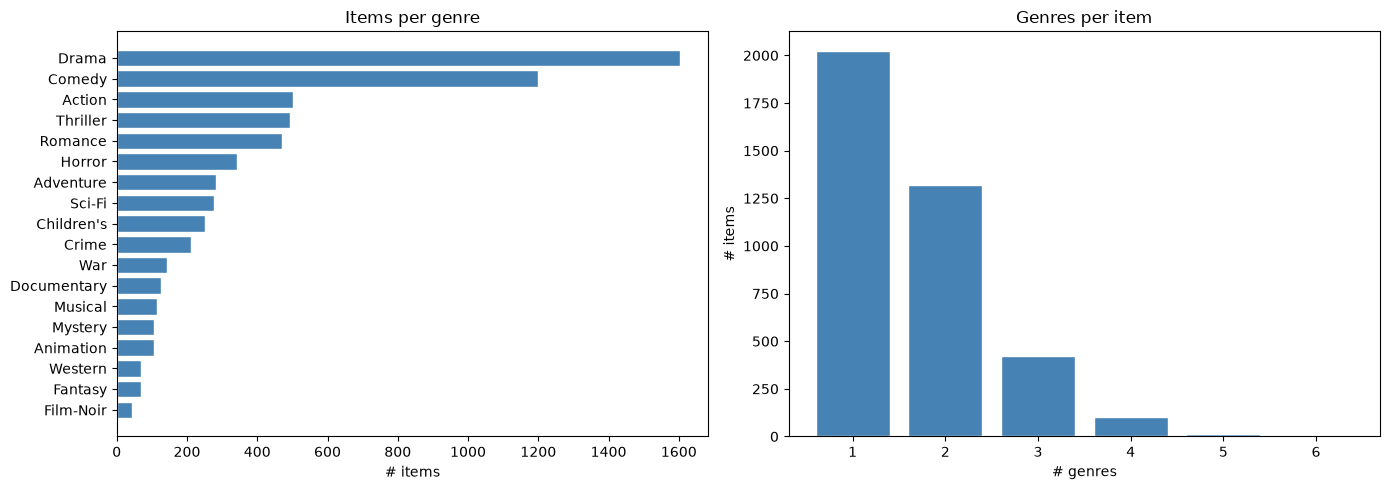

In [6]:
# Explode multi-genre strings
genres_exploded = (
    items["genres"]
    .str.split("|")
    .explode()
    .str.strip()
    .value_counts()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(genres_exploded.index, genres_exploded.values, color="steelblue", edgecolor="white")
axes[0].set_title("Items per genre")
axes[0].set_xlabel("# items")

# Number of genres per item
n_genres_per_item = items["genres"].str.split("|").apply(len)
genre_dist = n_genres_per_item.value_counts().sort_index()
axes[1].bar(genre_dist.index, genre_dist.values, color="steelblue", edgecolor="white")
axes[1].set_title("Genres per item")
axes[1].set_xlabel("# genres")
axes[1].set_ylabel("# items")

plt.tight_layout()
plt.show()

In [7]:
# Top 20 items by interaction count
item_counts = (
    interactions.groupby("item_id")
    .size()
    .rename("n_interactions")
    .reset_index()
    .merge(items[["item_id", "title"]], on="item_id")
    .sort_values("n_interactions", ascending=False)
    .head(20)
)
item_counts[["title", "n_interactions"]]

,title,n_interactions
1916,American Beauty (1999),3428
1640,Star Wars: Episode IV - A New Hope (1977),2991
191,Star Wars: Episode V - The Empire Strikes Back...,2990
208,Star Wars: Episode VI - Return of the Jedi (1983),2883
3182,Jurassic Park (1993),2672
1025,Saving Private Ryan (1998),2653
3301,Terminator 2: Judgment Day (1991),2649
1610,"Matrix, The (1999)",2590
272,Back to the Future (1985),2583
3306,"Silence of the Lambs, The (1991)",2578


## 5  Interaction volume — long-tail distributions

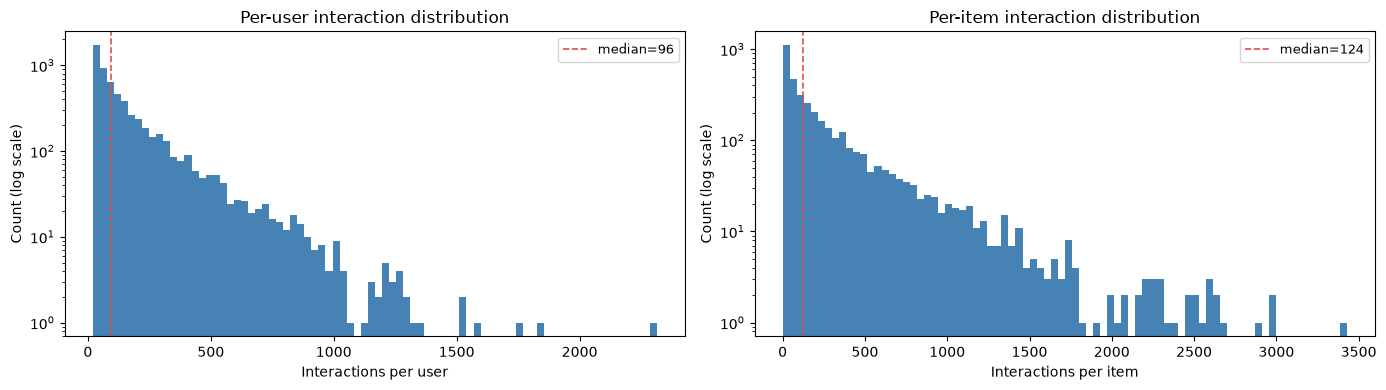

Per-user:
count    6040.0
mean      165.6
std       192.7
min        20.0
25%        44.0
50%        96.0
75%       208.0
max      2314.0
dtype: str

Per-item:
count    3706.0
mean      269.9
std       384.0
min         1.0
25%        33.0
50%       123.5
75%       350.0
max      3428.0
dtype: str


In [8]:
per_user = interactions.groupby("user_id").size()
per_item = interactions.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, series, label in [
    (axes[0], per_user, "user"),
    (axes[1], per_item, "item"),
]:
    ax.hist(series, bins=80, color="steelblue", edgecolor="none", log=True)
    ax.set_xlabel(f"Interactions per {label}")
    ax.set_ylabel("Count (log scale)")
    ax.set_title(f"Per-{label} interaction distribution")
    q = series.quantile([0.25, 0.5, 0.75])
    ax.axvline(q[0.5], color="#d9534f", linestyle="--", linewidth=1.2,
               label=f"median={q[0.5]:.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Per-user:")
print(per_user.describe().map("{:.1f}".format))
print()
print("Per-item:")
print(per_item.describe().map("{:.1f}".format))

In [9]:
# Items with zero interactions (not in interactions table)
items_with_interactions = interactions["item_id"].unique()
cold_items = items[~items["item_id"].isin(items_with_interactions)]
print(f"Items with at least one interaction : {len(items_with_interactions):,}")
print(f"Items with zero interactions        : {len(cold_items):,}")
if not cold_items.empty:
    print(cold_items[["item_id", "title", "genres"]].head(10).to_string(index=False))

Items with at least one interaction : 3,706
Items with zero interactions        : 177
item_id                               title                genres
     51               Guardian Angel (1994) Action|Drama|Thriller
    109 Headless Body in Topless Bar (1995)                Comedy
    115    Happiness Is in the Field (1995)                Comedy
    143                        Gospa (1995)                 Drama
    284                 New York Cop (1996)          Action|Crime
    285                Beyond Bedlam (1993)          Drama|Horror
    395                 Desert Winds (1995)                 Drama
    399         Girl in the Cadillac (1995)                 Drama
    400                       Homage (1995)                 Drama
    403                   Two Crimes (1995)    Comedy|Crime|Drama


## 6  Temporal activity

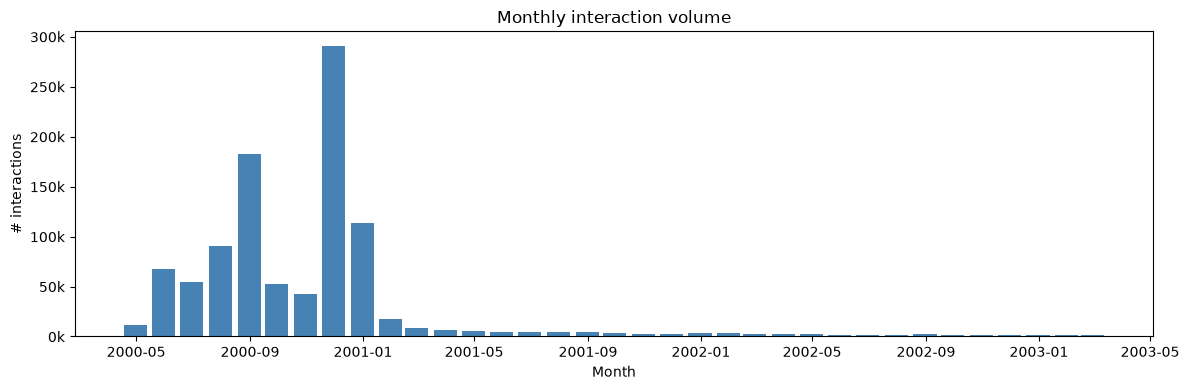

Earliest : 2000-04-25
Latest   : 2003-02-28
Span     : 1038 days


In [10]:
ts = pd.to_datetime(interactions["timestamp"], unit="s", utc=True).dt.tz_convert(None)
interactions_ts = interactions.assign(date=ts)

monthly = interactions_ts.set_index("date").resample("ME")["interaction_id"].count()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index, monthly.values, width=25, color="steelblue", edgecolor="none")
ax.set_title("Monthly interaction volume")
ax.set_xlabel("Month")
ax.set_ylabel("# interactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()

print(f"Earliest : {ts.min().date()}")
print(f"Latest   : {ts.max().date()}")
print(f"Span     : {(ts.max() - ts.min()).days} days")

## 7  Rating patterns by user demographics

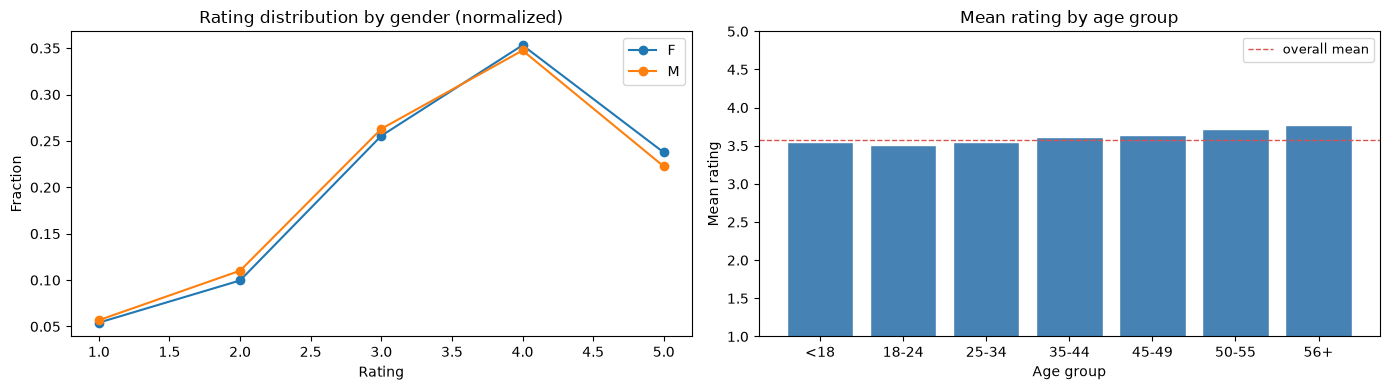

In [11]:
merged = interactions.merge(users[["user_id", "gender", "age"]], on="user_id")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating distribution by gender
for gender_val, group in merged.groupby("gender")["target_rating"]:
    counts = group.value_counts(normalize=True).sort_index()
    axes[0].plot(counts.index, counts.values, marker="o", label=gender_val)
axes[0].set_title("Rating distribution by gender (normalized)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Fraction")
axes[0].legend()

# Mean rating by age group
mean_by_age = (
    merged.groupby("age")["target_rating"]
    .mean()
    .rename(index=AGE_LABELS)
)
axes[1].bar(mean_by_age.index, mean_by_age.values, color="steelblue", edgecolor="white")
axes[1].set_title("Mean rating by age group")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Mean rating")
axes[1].set_ylim(1, 5)
axes[1].axhline(merged["target_rating"].mean(), color="#d9534f", linestyle="--",
                linewidth=1, label="overall mean")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()